<a href="https://colab.research.google.com/github/Khushitz/MACHINE-LEARNING/blob/MACHINE-LEARNING/Logistic_Regression_Multiclass_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()

In [3]:
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [4]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

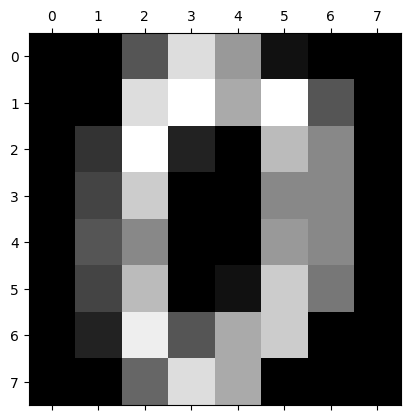

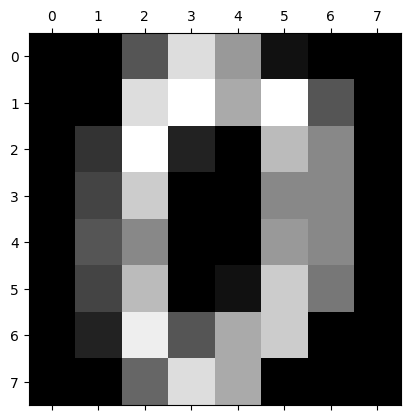

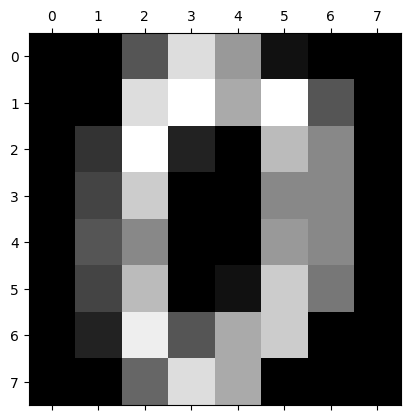

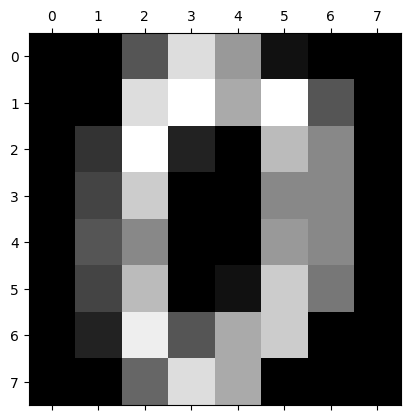

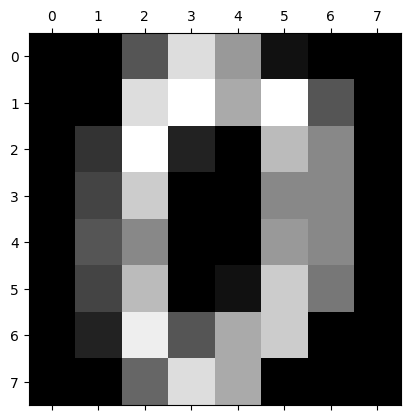

In [8]:
# plt.gray() Sets the colormap to grayscale. So the image will appear in black & white instead of colored.

for i in range(5):
  plt.matshow(digits.images[0])
#Displays the first image from the digits dataset.digits.images[0] is a 2D array (usually 8×8 for the sklearn digits dataset). Each value represents pixel intensity (0 = black, 16 = white).

In [12]:
digits.target[0:5] #Slicing the array to view the first five target values (labels) of the dataset

array([0, 1, 2, 3, 4])

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test = train_test_split(digits.data, digits.target)

In [17]:
len(x_train)

1347

In [18]:
len(x_test)

450

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [20]:
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [21]:
model.score(x_test,y_test)

0.9733333333333334

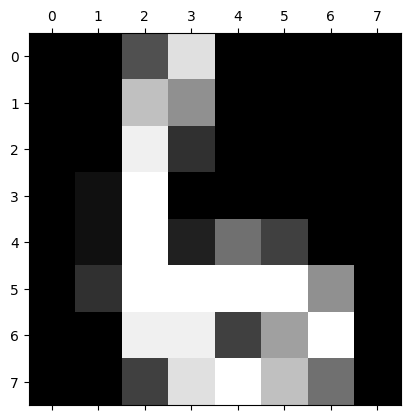

In [26]:

plt.matshow(digits.images[67])

In [27]:
digits.target[67]


np.int64(6)

In [28]:
model.predict([digits.data[67]]) #at 67 we have digit 6

array([6])

In [29]:
model.predict(digits.data[0:5])

array([0, 1, 2, 3, 4])

In [30]:
#where exactly now i want to know my model really actually fails that can be done through confusion matrics

y_predicted = model.predict(x_test)
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_predicted)
cm

array([[44,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 44,  0,  0,  0,  0,  0,  0,  1,  1],
       [ 0,  1, 42,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 43,  0,  0,  0,  0,  1,  1],
       [ 0,  0,  0,  0, 43,  0,  0,  0,  1,  0],
       [ 0,  0,  0,  1,  0, 42,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  1, 54,  0,  0,  0],
       [ 0,  0,  0,  1,  1,  0,  0, 46,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 42,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  0, 38]])

Text(95.72222222222221, 0.5, 'Truth')

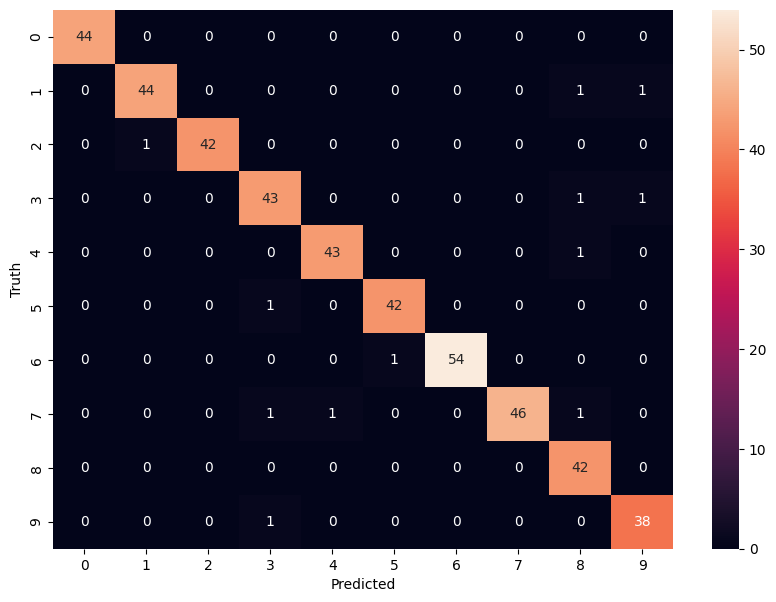

In [31]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot = True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
#here apart from 0 where we see other numbers lets say 1 so it should be 9 but out model actually predicted it to be 3


Confusion metrics are used to evaluate a classification model (like Logistic Regression).

It is a table that compares:

Actual values (real answers)

Predicted values (model’s answers)

For a binary classification (Yes/No), we get 4 values:

|                | Predicted Yes       | Predicted No        |
| -------------- | ------------------- | ------------------- |
| **Actual Yes** | True Positive (TP)  | False Negative (FN) |
| **Actual No**  | False Positive (FP) | True Negative (TN)  |


Accuracy → Overall correctness

Precision → How precise your positive predictions are

Recall → How many real positives you caught

F1 Score → Balance between precision & recall
